# Индивидуальное задание 2
## «Программные управления и движения. Вычисление функционала»

> Работу выполнил  
> студент 2 курса  
> ФМ/О ПМИ-1-2024 НМ  
> Усов Лев  

Вариант 9



$$
\dot x= \frac {u} {x} ​,~~t∈[0,3],~~x(0)=1,
$$
$$
I[u(⋅)]=∫_0^3​\sqrt{x^2(τ)+u^2(τ)}
​dτ−x^2(3)
$$
$$
\begin{equation*}
u^{(1)}(\cdot) = 
 \begin{cases}
   -t^2, & t \in [0,1)\\
   0, & t \in [1,2)\\
   t^3, & t \in [2,3]\\
 \end{cases}
\end{equation*}
$$
$$
\begin{equation*}
u^{(2)}(\cdot) = 
 \begin{cases}
   sin(t), & t \in [0,1)\\
   cos(t), & t \in [1,2)\\
   -t, & t \in [2,3]\\
 \end{cases}
\end{equation*}
$$

In [1]:
import numpy as np
from scipy.integrate import solve_ivp, trapezoid
import matplotlib.pyplot as plt

# Определяем кусочные управления
$$\begin{equation*}
u^{(1)}(\cdot) = 
 \begin{cases}
   -t^2, & t \in [0,1)\\
   0, & t \in [1,2)\\
   t^3, & t \in [2,3]\\
 \end{cases}
\end{equation*}$$   
$$\begin{equation*}
u^{(2)}(\cdot) = 
 \begin{cases}
   sin(t), & t \in [0,1)\\
   cos(t), & t \in [1,2)\\
   -t, & t \in [2,3]\\
 \end{cases}
\end{equation*}$$

In [2]:
def u1(t):
    """Управление u^{(1)}(t)"""
    return np.piecewise(t,
                        [t < 1, (t >= 1) & (t < 2), t >= 2],
                        [lambda t: -t**2, 0, lambda t: t**3])

def u2(t):
    """Управление u^{(2)}(t)"""
    return np.piecewise(t,
                        [t < 1, (t >= 1) & (t < 2), t >= 2],
                        [np.sin, np.cos, lambda t: -t])

Функция правой части ОДУ (dx/dt = u(t)/x)

In [3]:
def ode_rhs(t, x, u_func):
    # Чтобы избежать деления на 0, добавим крошечное число 
    return u_func(t) / (x + 1e-12)

Функция для вычисления функционала I[u] для заданного управления

In [4]:
def compute_functional(u_func, u_name):
    # 1. Решаем ОДУ
    # Создаем плотную сетку времени для более точного интегрирования
    t_eval = np.linspace(0, 3, 10001) # Больше точек для кусочных функций
    sol = solve_ivp(ode_rhs, [0, 3], [1.0], args=(u_func,),
                    t_eval=t_eval, method='RK45', rtol=1e-9, atol=1e-12)

    t = sol.t
    x = sol.y[0]

    # 2. Вычисляем управление и подинтегральное выражение на той же сетке
    u_vals = u_func(t)
    integrand = np.sqrt(x**2 + u_vals**2)

    # 3. Вычисляем интеграл методом трапеций (очень точный на плотной сетке)
    integral_val = trapezoid(integrand, t)

    # 4. Вычисляем терминальный член
    terminal_cost = x[-1]**2  # x(3) - последнее значение

    # 5. Полный функционал
    I_u = integral_val - terminal_cost

    # Выводим результат
    print(f"Для управления {u_name}:")
    print(f"  Значение интеграла ∫√(x²+u²)dt = {integral_val:.6f}")
    print(f"  Терминальный член x²(3) = {terminal_cost:.6f}")
    print(f"  Функционал I[u] = {I_u:.6f}")
    print()

    # Возвращаем данные для построения графиков
    return t, x, u_vals, I_u

Поскольку в задаче нам даны "на выбор" две функции управления, далее мы будем их сравнивать их оптимальность

Численное решение задачи и вычисление функционалов
Для управления u^{(1)} (кусочно-полиномиальное):
  Значение интеграла ∫√(x²+u²)dt = 18.198312
  Терминальный член x²(3) = 32.833333
  Функционал I[u] = -14.635021

Для управления u^{(2)} (тригонометрическо-линейное):
  Значение интеграла ∫√(x²+u²)dt = 3.873395
  Терминальный член x²(3) = 0.000496
  Функционал I[u] = 3.872899

Сравнение: I[u^(1)] < I[u^(2)]
Разница: |I[u^(1)] - I[u^(2)]| = 18.507920


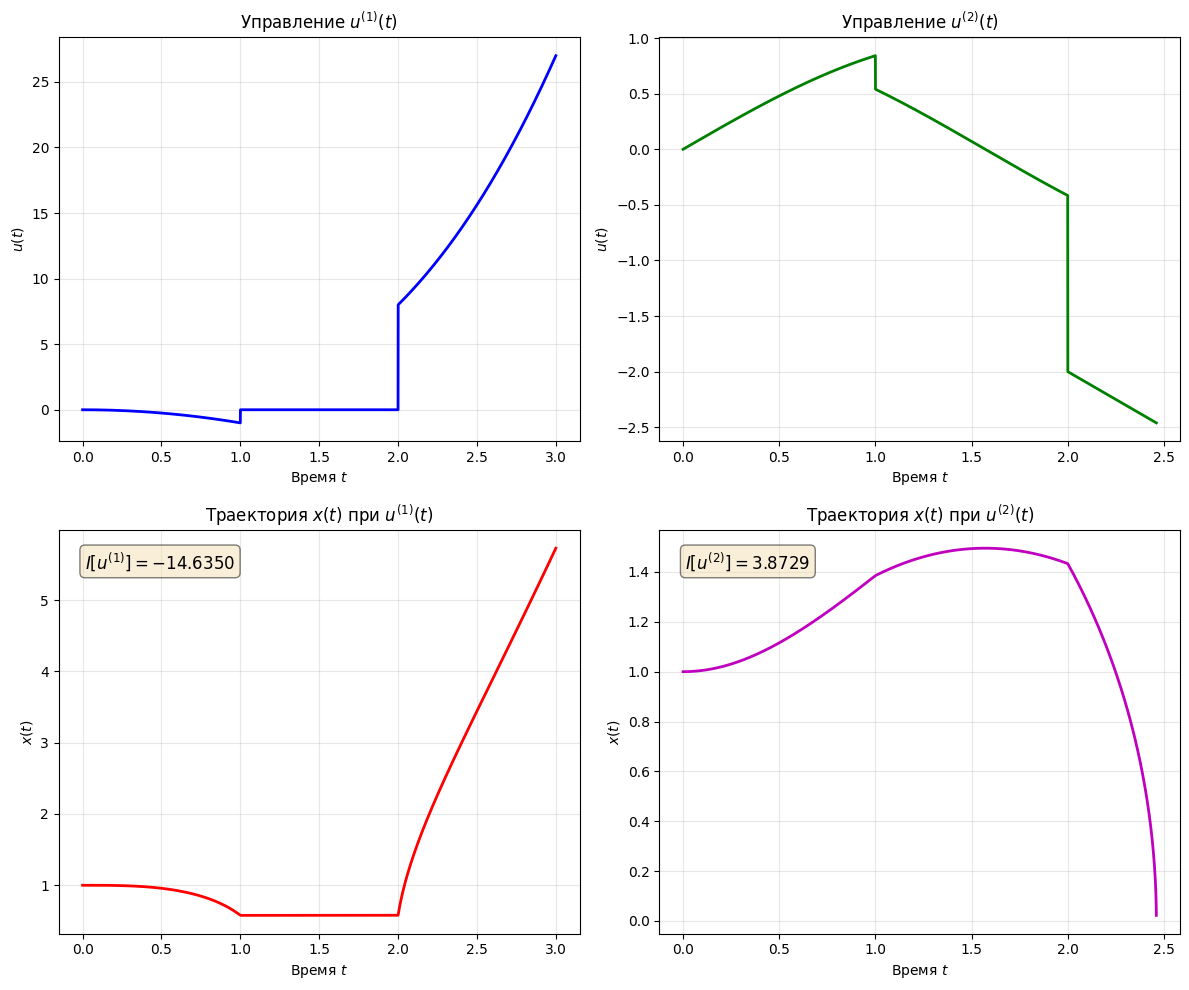

In [5]:
# --- Основные вычисления ---
print("="*50)
print("Численное решение задачи и вычисление функционалов")
print("="*50)

# Вычисляем для первого управления
t1, x1, u_vals1, I_u1 = compute_functional(u1, "u^{(1)} (кусочно-полиномиальное)")

# Вычисляем для второго управления
t2, x2, u_vals2, I_u2 = compute_functional(u2, "u^{(2)} (тригонометрическо-линейное)")

# Сравниваем функционалы
print("="*50)
print(f"Сравнение: I[u^(1)] {'<' if I_u1 < I_u2 else '>'} I[u^(2)]")
print(f"Разница: |I[u^(1)] - I[u^(2)]| = {abs(I_u1 - I_u2):.6f}")
print("="*50)

# --- Построение графиков ---
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Графики для u1
axs[0, 0].plot(t1, u_vals1, 'b-', linewidth=2)
axs[0, 0].set_title('Управление $u^{(1)}(t)$')
axs[0, 0].set_xlabel('Время $t$')
axs[0, 0].set_ylabel('$u(t)$')
axs[0, 0].grid(True, alpha=0.3)

axs[1, 0].plot(t1, x1, 'r-', linewidth=2)
axs[1, 0].set_title('Траектория $x(t)$ при $u^{(1)}(t)$')
axs[1, 0].set_xlabel('Время $t$')
axs[1, 0].set_ylabel('$x(t)$')
axs[1, 0].grid(True, alpha=0.3)
axs[1, 0].text(0.05, 0.95, f'$I[u^{{(1)}}] = {I_u1:.4f}$',
               transform=axs[1, 0].transAxes, fontsize=12,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Графики для u2
axs[0, 1].plot(t2, u_vals2, 'g-', linewidth=2)
axs[0, 1].set_title('Управление $u^{(2)}(t)$')
axs[0, 1].set_xlabel('Время $t$')
axs[0, 1].set_ylabel('$u(t)$')
axs[0, 1].grid(True, alpha=0.3)

axs[1, 1].plot(t2, x2, 'm-', linewidth=2)
axs[1, 1].set_title('Траектория $x(t)$ при $u^{(2)}(t)$')
axs[1, 1].set_xlabel('Время $t$')
axs[1, 1].set_ylabel('$x(t)$')
axs[1, 1].grid(True, alpha=0.3)
axs[1, 1].text(0.05, 0.95, f'$I[u^{{(2)}}] = {I_u2:.4f}$',
               transform=axs[1, 1].transAxes, fontsize=12,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

Управление u(1) существенно лучше по заданному критерию, так как оно обеспечивает огромный выигрыш в конечном состоянии, перекрывающий затраты в интеграле. Управление u(2) приводит к почти полному обнулению системы и потому неэффективно.